## KNN - K nearest neighbours

In [1]:

from sklearn.datasets import load_wine
import pandas as pd 

wine = load_wine()
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [2]:

wine["feature_names"]


['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [3]:

len(wine["feature_names"])

13

In [4]:

wine["target"]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

## Correlation heatmap

In [5]:

wine["target_names"]

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [6]:

wine["target"].shape, wine["data"].shape

((178,), (178, 13))

In [7]:


df = pd.DataFrame(wine["data"], columns=wine["feature_names"])
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [8]:
df_wine_classes = pd.DataFrame(wine["target"],columns=["wine_class"])
df_wine_classes.head()

,wine_class
0,0
1,0
2,0
3,0
4,0


In [9]:

df_with_target = pd.concat([df, df_wine_classes], axis=1)
df_with_target.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [10]:

df_with_target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  wine_

<Axes: >

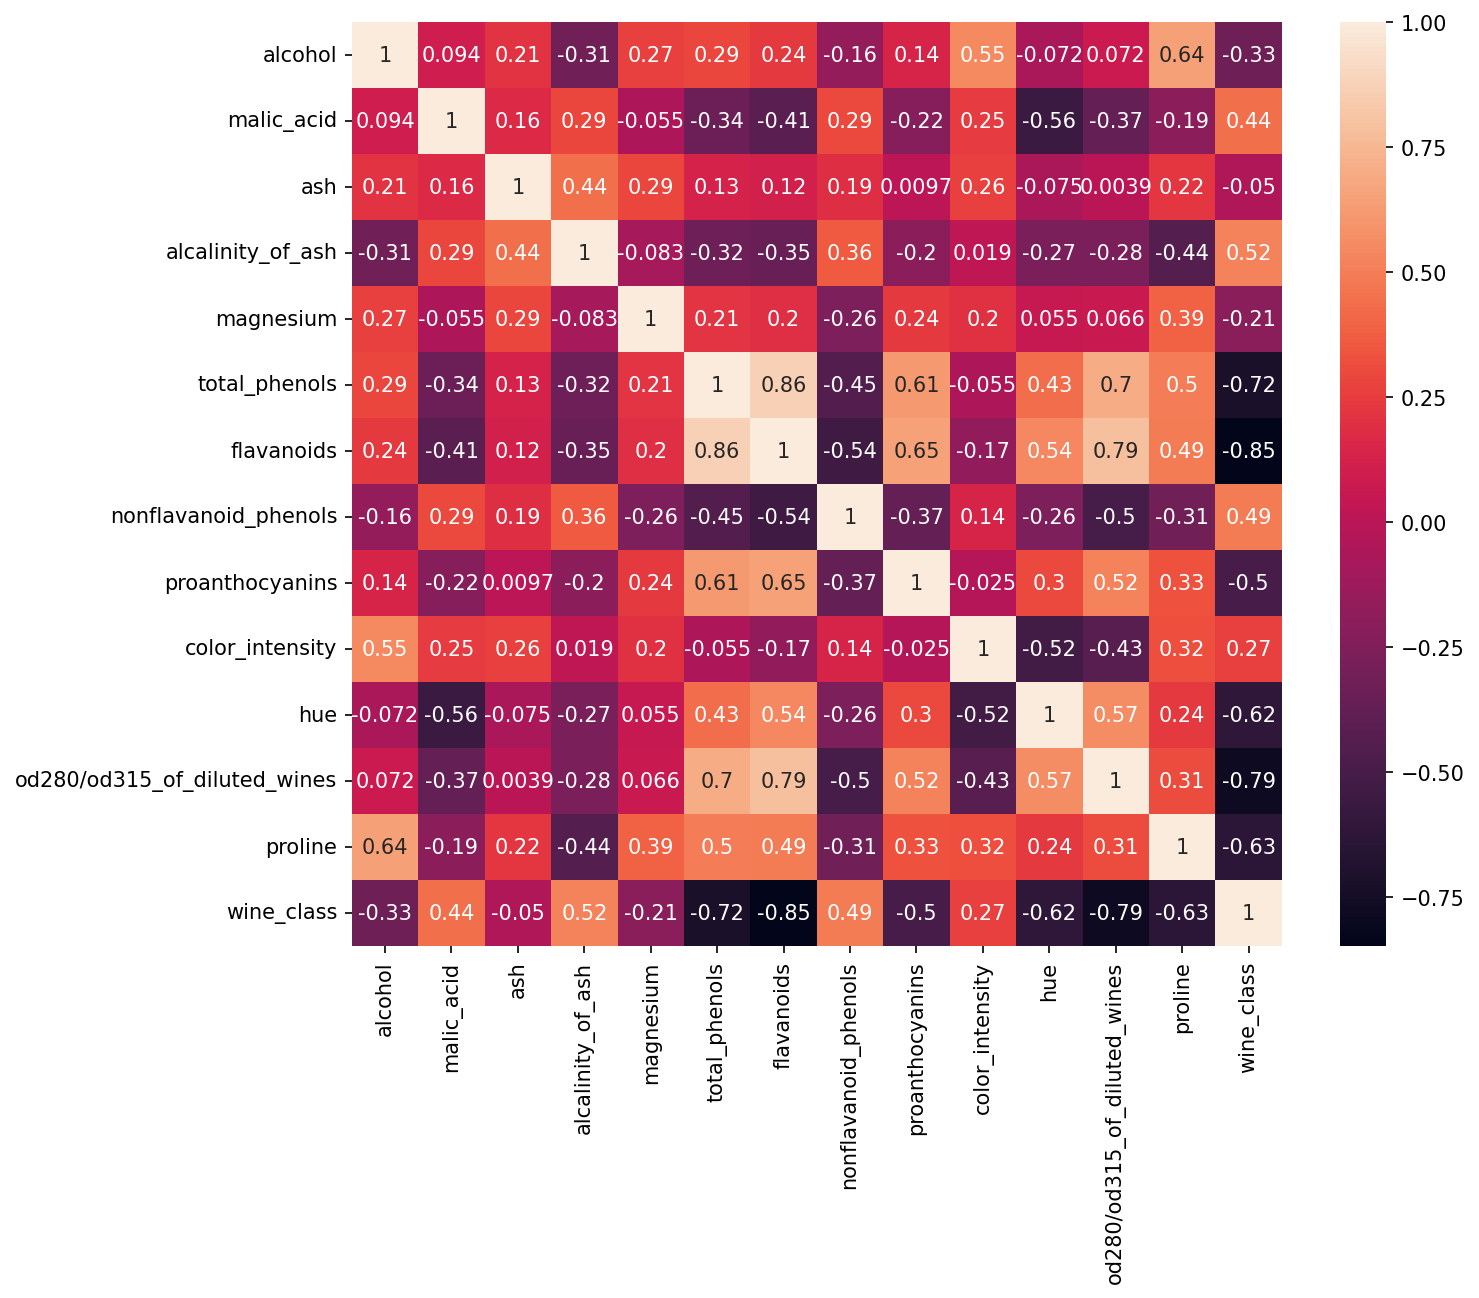

In [11]:

import matplotlib.pyplot as plt 
import seaborn as sns 

fig,ax = plt.subplots(1, figsize = (10,8), dpi = 150)

sns.heatmap(df_with_target.corr(), annot=True)

In [12]:


df_feature_select = df_with_target.drop(["ash", "total_phenols", "magnesium"], axis=1)
df_feature_select.head()

,alcohol,malic_acid,alcalinity_of_ash,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,15.6,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,11.2,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,18.6,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,16.8,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,21.0,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## KNN model


divide into feature matrix and target vector

In [13]:
X, y = df_feature_select.drop("wine_class", axis=1), df_feature_select["wine_class"]
X.head()

,alcohol,malic_acid,alcalinity_of_ash,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,15.6,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,11.2,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,18.6,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,16.8,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,21.0,2.69,0.39,1.82,4.32,1.04,2.93,735.0



## train|test split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

X_train.shape

(89, 10)

## 

## scale dataset

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

scaled_X_train.min(), scaled_X_train.max(), scaled_X_test.min(), scaled_X_test.max()

(np.float64(0.0),
 np.float64(1.0),
 np.float64(-0.05077262693156731),
 np.float64(1.2428256070640176))

## KNN model

In [16]:

from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=1)
model.fit(scaled_X_train, y_train)

y_pred = model.predict(scaled_X_test)

In [17]:

y_test.values, y_pred

(array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
        1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1,
        2, 0, 1, 1, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 0,
        0, 2, 0, 0, 1, 2, 1, 0, 2, 1, 0, 2, 1, 1, 0, 1, 0, 0, 1, 0, 0, 2,
        1]),
 array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 2, 0, 1, 1, 1, 0, 1, 0, 1,
        1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1,
        2, 0, 1, 1, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 0,
        0, 2, 0, 0, 1, 2, 1, 0, 2, 0, 0, 2, 1, 1, 0, 1, 0, 0, 1, 1, 0, 2,
        1]))


## evaluate model

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       0.97      0.94      0.96        34
           2       0.96      1.00      0.98        22

    accuracy                           0.97        89
   macro avg       0.97      0.97      0.97        89
weighted avg       0.97      0.97      0.97        89



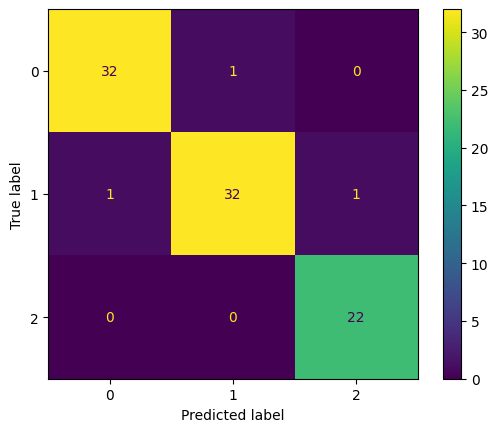

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot();

## Tune hyperparameter K (n_neighbours) with elbow plot

In [19]:
from sklearn.metrics import accuracy_score

error = 1-accuracy_score(y_test, y_pred)
error

0.0337078651685393

[Text(0.5, 0, 'k neighbours'),
 Text(0, 0.5, 'error'),
 Text(0.5, 1.0, 'Elbowplot to choose')]

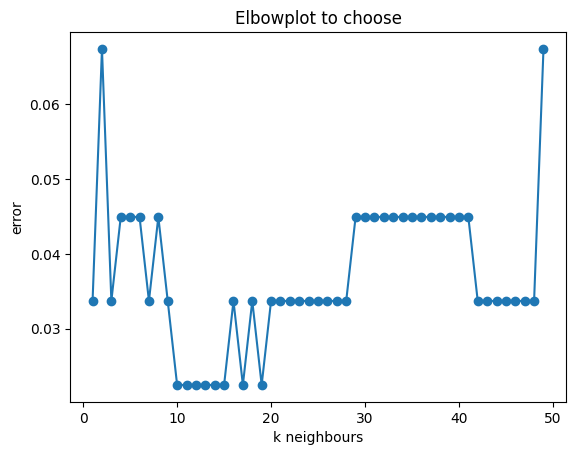

In [20]:
error_list = []
for k in range(1, 50):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(scaled_X_train, y_train)
    y_pred = model.predict(scaled_X_test)
    error = 1-accuracy_score(y_test, y_pred)
    error_list.append(error)

error_list

fig,ax = plt.subplots(1)
ax.plot(range(1,50), error_list, "-o")
ax.set(xlabel = "k neighbours", ylabel = "error", title = "Elbowplot to choose")

## Plot a graph

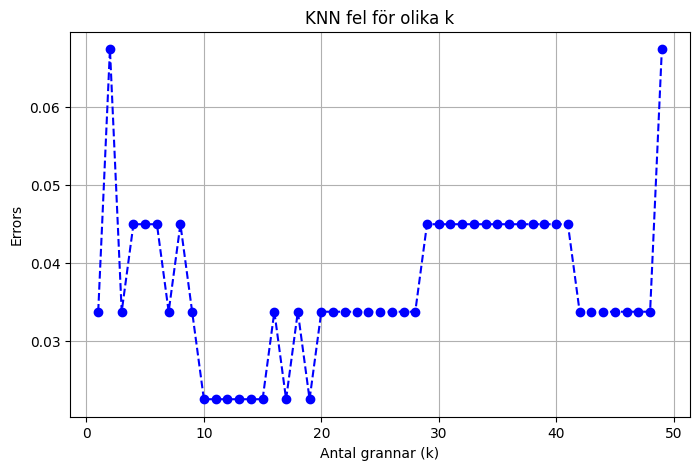

In [21]:
import matplotlib.pyplot as plt

# x-värdena = k från 1 till 49
k_values = range(1, 50)

plt.figure(figsize=(8,5))
plt.plot(k_values, error_list, marker='o', linestyle='--', color='b')
plt.xlabel("Antal grannar (k)")
plt.ylabel("Errors")
plt.title("KNN fel för olika k")
plt.grid(True)
plt.show()


Here, choose k = 10 or 11 adn train on all data (train and test part). save/export model 

To be more robust
- do train/val/test/split (use train/test/spilt twice)
- calculare error based on validation data
- choose k on elbow plot with validation data
- train on train + validation data
- evaluate on all data
- train on all data
- export model